In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

# Load and resize
img_left  = cv2.imread('data/Motorcycle-perfect/im0.png')
img_right = cv2.imread('data/Motorcycle-perfect/im1.png')
img_left  = cv2.resize(img_left,  (741, 500))
img_right = cv2.resize(img_right, (741, 500))

gray_left  = cv2.cvtColor(img_left,  cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

num_disparities = 96  # move to 96 once the pipeline is working
block_size = 5        # patch size, odd number

# Camera parameters
scale  = 741 / 2964
f      = 3979.911 * scale
cx     = 1244.772 * scale
cy     = 1019.507 * scale
B      = 193.001
doffs  = 124.343 * scale


Cost Volume Loop

In [41]:
h, w = gray_left.shape
pad = block_size // 2

# create empty cost volume
cost_volume = np.zeros((h, w, num_disparities))
print(cost_volume.shape)


for d in tqdm(range(num_disparities), desc="Computing cost volume"):
    # interations to make sure that nothing goes out of bounds
    for y in range(pad, h - pad):
        for x in range(pad + d, w-pad):

            # extract left patch centered at (x, y)
            left_patch = gray_left[y-pad:y+pad+1, x-pad:x+pad+1]
            # extract right patch centered at (x-d, y)
            right_patch = gray_right[y-pad:y+pad+1, x-d-pad:x-d+pad+1]  

            # compute SSD between them
            cost_volume[y, x, d] = np.sum((left_patch - right_patch) ** 2)


            
disparity_naive = np.argmin(cost_volume, axis=2)

(500, 741, 96)


Computing cost volume: 100%|██████████| 96/96 [02:08<00:00,  1.34s/it]


In [42]:
disparity_naive = np.argmin(cost_volume, axis=2)

In [43]:
def sgm_aggregation(cost_volume, P1=10, P2=120):
    h, w, num_d = cost_volume.shape
    num_directions = 8
    
    # all 8 directions (dy, dx)
    directions = [
        (0, 1),   # right
        (0, -1),  # left
        (1, 0),   # down
        (-1, 0),  # up
        (1, 1),   # down-right
        (1, -1),  # down-left
        (-1, 1),  # up-right
        (-1, -1)  # up-left
    ]
    
    # accumulated cost across all directions
    S = np.zeros_like(cost_volume)  # (h, w, num_d)

    for dy, dx in tqdm(directions, desc="sgm_aggregation_loop"):
        # L holds the running path cost for this direction
        L = np.zeros_like(cost_volume)  # (h, w, num_d)
        
        # define iteration order so we always process the previous pixel first
        y_range = range(h) if dy >= 0 else range(h-1, -1, -1)
        x_range = range(w) if dx >= 0 else range(w-1, -1, -1)
        
        for y in y_range:
            for x in x_range:
                py, px = y - dy, x - dx  # previous pixel along this path
                
                # if no previous pixel (we're at the border), cost is just raw cost
                if not (0 <= py < h and 0 <= px < w):
                    L[y, x, :] = cost_volume[y, x, :]
                    continue
                
                prev = L[py, px, :]  # shape: (num_d,)
                min_prev = np.min(prev)
                
                # vectorized version of the recursion for all d at once
                same      = prev                                    # L(p-r, d)
                minus_one = np.roll(prev, 1);  minus_one[0]  = np.inf  # L(p-r, d-1)
                plus_one  = np.roll(prev, -1); plus_one[-1]  = np.inf  # L(p-r, d+1)
                
                L[y, x, :] = cost_volume[y, x, :] + np.minimum.reduce([
                    same,
                    minus_one + P1,
                    plus_one  + P1,
                    np.full(num_d, min_prev + P2)
                ]) - min_prev  # subtract min_prev to prevent cost explosion
        
        print(f"Direction ({dy},{dx}) — L mean: {L.mean():.2f}, S mean: {S.mean():.2f}")
                
        S += L
    print(f"Final S mean: {S.mean():.2f}, expected ~{cost_volume.mean():.2f} × 8 = {cost_volume.mean()*8:.2f}")
    return S

# --- run it ---
S = sgm_aggregation(cost_volume, P1=300, P2=2300)
disparity_sgm = np.argmin(S, axis=2)


sgm_aggregation_loop:  12%|█▎        | 1/8 [00:06<00:45,  6.48s/it]

Direction (0,1) — L mean: 3921.61, S mean: 0.00


sgm_aggregation_loop:  25%|██▌       | 2/8 [00:12<00:38,  6.49s/it]

Direction (0,-1) — L mean: 4052.39, S mean: 3921.61


sgm_aggregation_loop:  38%|███▊      | 3/8 [00:19<00:31,  6.38s/it]

...

Direction (1,-1) — L mean: 4036.64, S mean: 19723.91


sgm_aggregation_loop:  88%|████████▊ | 7/8 [00:44<00:06,  6.40s/it]

Direction (-1,1) — L mean: 3913.34, S mean: 23760.55


sgm_aggregation_loop: 100%|██████████| 8/8 [00:51<00:00,  6.42s/it]

Direction (-1,-1) — L mean: 4037.12, S mean: 27673.89
Final S mean: 31711.01, expected ~1936.57 × 8 = 15492.54


In [44]:


# ── OpenCV SGBM ──────────────────────────────────────────────────────────────
sgbm = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=num_disparities,   # must be divisible by 16
    blockSize=block_size,
    P1=8  * 3 * block_size**2,        # OpenCV's recommended formula: 8*cn*bsize²
    P2=32 * 3 * block_size**2,        # 32*cn*bsize²
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY   # full 8-direction SGM
)

# SGBM returns disparity * 16 as int16 → divide to get float
disp_cv_raw = sgbm.compute(gray_left, gray_right).astype(np.float32) / 16.0
disp_cv_raw[disp_cv_raw < 0] = np.nan   # invalid pixels flagged as -1 by OpenCV



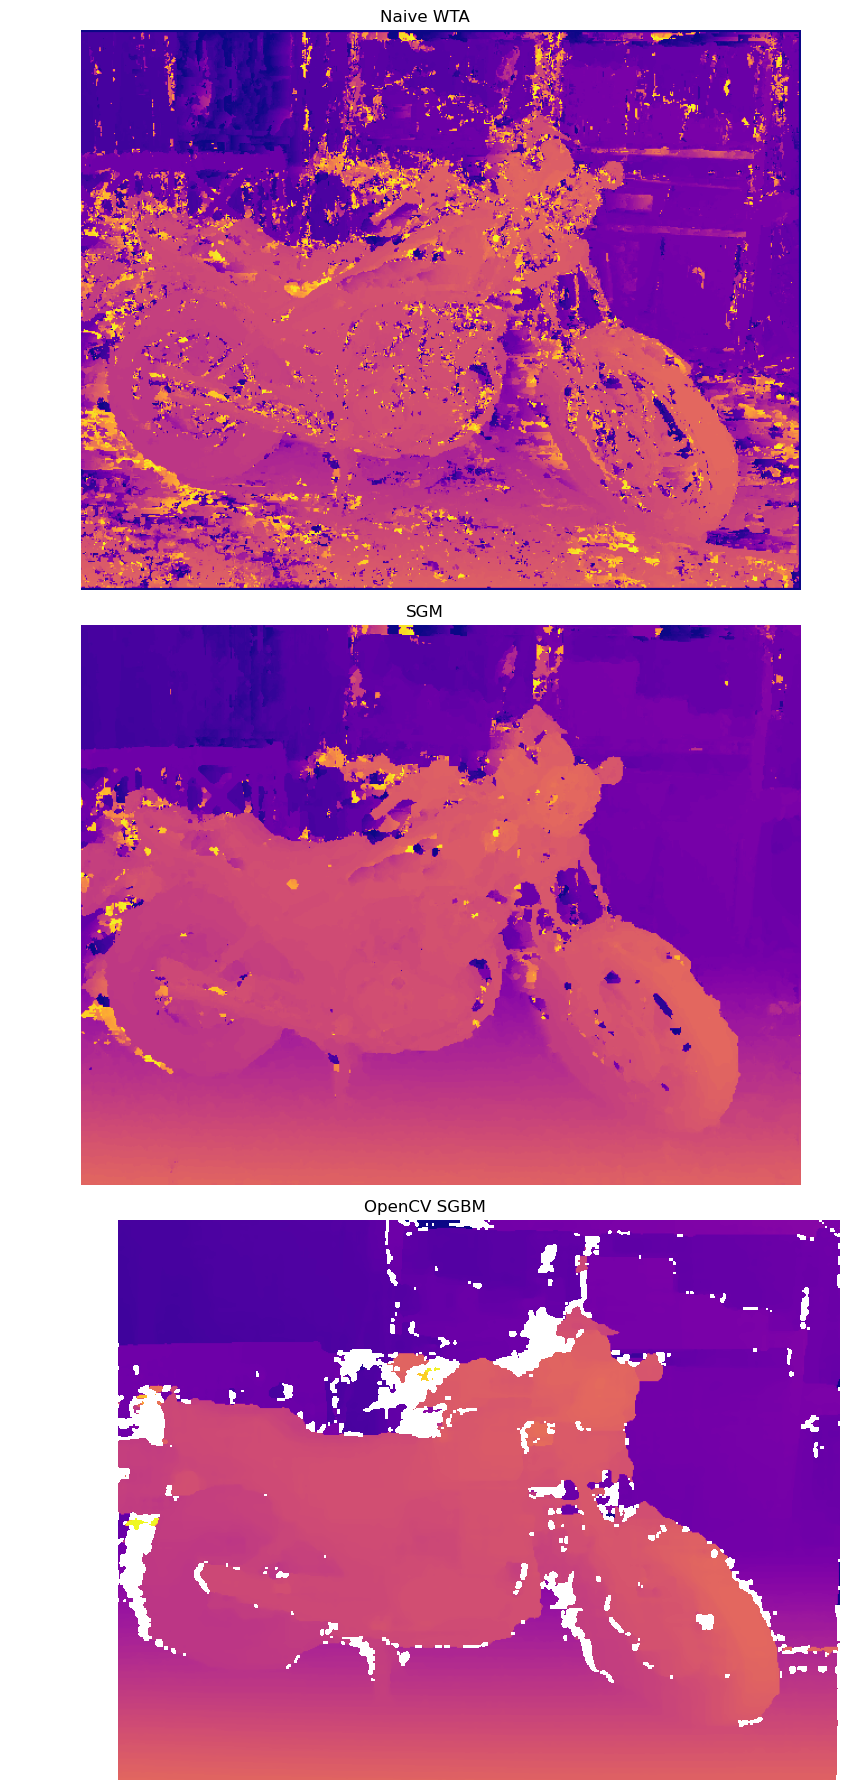

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# Naive WTA
disp_naive_show = disparity_naive.astype(np.float32)
disp_naive_show[:, :pad + num_disparities] = np.nan
axes[0].imshow(disp_naive_show[:, 70:], cmap='plasma')
axes[0].set_title('Naive WTA')
axes[0].axis('off')

# Your SGM
disp_sgm_show = disparity_sgm.astype(np.float32)
disp_sgm_show[:, :pad + num_disparities] = np.nan
axes[1].imshow(disp_sgm_show[:, 70:], cmap='plasma')
axes[1].set_title('SGM')
axes[1].axis('off')

# OpenCV SGBM
disp_cv_show = disp_cv_raw.copy()
# disp_cv_show[:, :70] = np.nan
axes[2].imshow(disp_cv_show, cmap='plasma')
axes[2].set_title('OpenCV SGBM')
axes[2].axis('off')

plt.tight_layout()
plt.savefig("figures/disparity_comparison_all3")
plt.show()

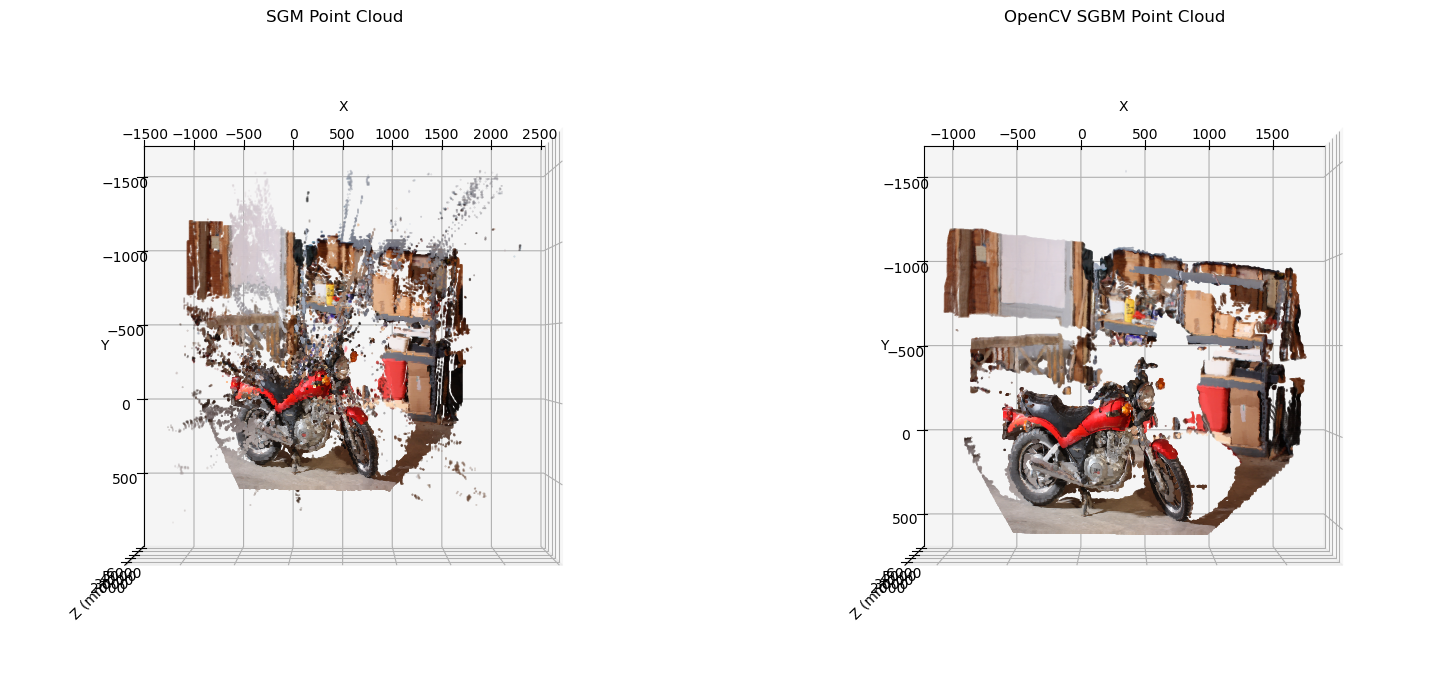

In [47]:
def make_point_cloud(disp, img, f, B, cx, cy, doffs, h, w, z_max=8000):
    disp = disp.astype(np.float32).copy()
    disp[disp == 0] = np.nan

    Z = (f * B) / (disp + doffs)
    Z[Z > z_max] = np.nan
    Z[Z < 0]     = np.nan

    ys, xs = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
    X = (xs - cx) * Z / f
    Y = (ys - cy) * Z / f

    mask   = np.isfinite(Z)
    points = np.stack([X[mask], Y[mask], Z[mask]], axis=1)
    colors = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)[mask] / 255.0
    return points, colors


# ── SGM point cloud ───────────────────────────────────────────────────────────
disp_sgm_pc = disparity_sgm.astype(np.float32)
disp_sgm_pc[:, :pad + num_disparities] = np.nan
points_sgm, colors_sgm = make_point_cloud(disp_sgm_pc, img_left, f, B, cx, cy, doffs, h, w)

# ── OpenCV point cloud ────────────────────────────────────────────────────────
disp_cv_pc = disp_cv_raw.copy()
disp_cv_pc[:, :pad + num_disparities] = np.nan
points_cv, colors_cv = make_point_cloud(disp_cv_pc, img_left, f, B, cx, cy, doffs, h, w)

# ── Plot side by side ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 7))

for i, (points, colors, title) in enumerate([
    (points_sgm, colors_sgm, 'SGM Point Cloud'),
    (points_cv,  colors_cv,  'OpenCV SGBM Point Cloud'),
]):
    ax = fig.add_subplot(1, 2, i+1, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors, s=0.1)
    ax.set_title(title)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z (mm)')
    ax.view_init(elev=-90, azim=-90)

plt.tight_layout()
plt.savefig("figures/sgm_point_cloud_comparison")
plt.show()